1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Affichage
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

2. Chargement du dataset

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head(10)

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1
5,CUST_00005,40,Male,Employed,76906.812198,84,1260.654535,2,227.110255,36,0.000000,63,5,7,727,4,1267.328320,2,0,0,5424.024525,0
6,CUST_00006,58,Female,Employed,14485.730000,48,1437.594031,3,20.000000,34,633.589112,14,11,0,754,1,13356.388072,2,1,0,9004.582223,1
7,CUST_00007,38,Female,Employed,67355.217921,173,1959.997183,0,426.243321,7,788.186496,72,15,2,307,5,18254.853569,5,0,0,12632.805584,1
8,CUST_00008,42,Female,Employed,62980.151376,132,2220.699649,0,584.181270,42,618.813748,15,5,3,515,3,8376.686391,7,0,0,9538.756785,1
9,CUST_00009,30,Female,Self-Employed,55751.973822,99,2527.700512,3,1025.489663,2,180.263305,45,1,4,583,1,17976.626918,6,0,0,2896.670257,1


3. Informations générales

In [3]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.info()

Nombre de lignes : 5000
Nombre de colonnes : 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null   int64  
 12  online_transfer_frequency   5000 non-null 

5. Vérification des valeurs nulles

In [4]:
df.isnull().sum()


customer_id                   0
age                           0
gender                        0
employment_status             0
annual_income                 0
account_age_months            0
avg_monthly_balance           0
num_deposits_per_month        0
avg_deposit_amount            0
debit_card_usage_frequency    0
debit_card_spending           0
mobile_banking_logins         0
online_transfer_frequency     0
atm_withdrawal_frequency      0
credit_score                  0
num_open_loans                0
total_outstanding_debt        0
late_payment_count            0
loan_default_history          0
fraud_flag                    0
loan_application_amount       0
credit_risk                   0
dtype: int64

6. Détection des doublons

In [5]:
duplicates = df.duplicated().sum()

print("Nombre de doublons :", duplicates)

Nombre de doublons : 0


7. Types des variables

In [6]:
df.dtypes

customer_id                    object
age                             int64
gender                         object
employment_status              object
annual_income                 float64
account_age_months              int64
avg_monthly_balance           float64
num_deposits_per_month          int64
avg_deposit_amount            float64
debit_card_usage_frequency      int64
debit_card_spending           float64
mobile_banking_logins           int64
online_transfer_frequency       int64
atm_withdrawal_frequency        int64
credit_score                    int64
num_open_loans                  int64
total_outstanding_debt        float64
late_payment_count              int64
loan_default_history            int64
fraud_flag                      int64
loan_application_amount       float64
credit_risk                     int64
dtype: object

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

print("Variables numériques :")
print(num_cols)

print("\nVariables catégorielles :")
print(cat_cols)

Variables numériques :
Index(['age', 'annual_income', 'account_age_months', 'avg_monthly_balance',
       'num_deposits_per_month', 'avg_deposit_amount',
       'debit_card_usage_frequency', 'debit_card_spending',
       'mobile_banking_logins', 'online_transfer_frequency',
       'atm_withdrawal_frequency', 'credit_score', 'num_open_loans',
       'total_outstanding_debt', 'late_payment_count', 'loan_default_history',
       'fraud_flag', 'loan_application_amount', 'credit_risk'],
      dtype='object')

Variables catégorielles :
Index(['customer_id', 'gender', 'employment_status'], dtype='object')


8.Distribution des variables numériques

# 2. ANALYSE EXPLORATOIRE DES VARIABLES
# ============================================================================

# 2.1 Distribution de l'âge

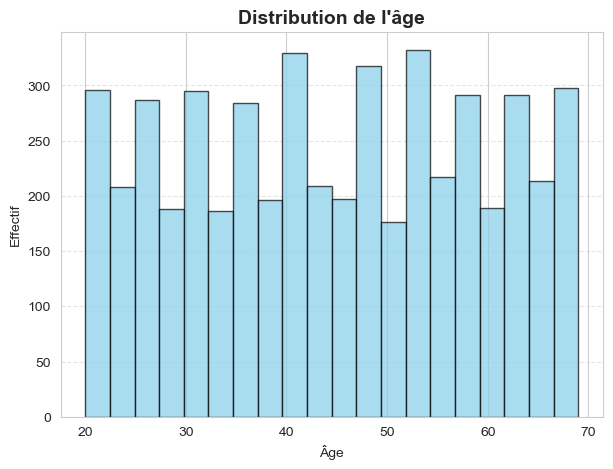

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

# Histogramme de l'âge
ax.hist(
    df['age'].dropna(),
    bins=20,
    edgecolor='black',
    color='skyblue',
    alpha=0.7
)

ax.set_title("Distribution de l'âge", fontsize=14, fontweight='bold')
ax.set_xlabel("Âge")
ax.set_ylabel("Effectif")
ax.grid(axis='y', linestyle='--', alpha=0.5)

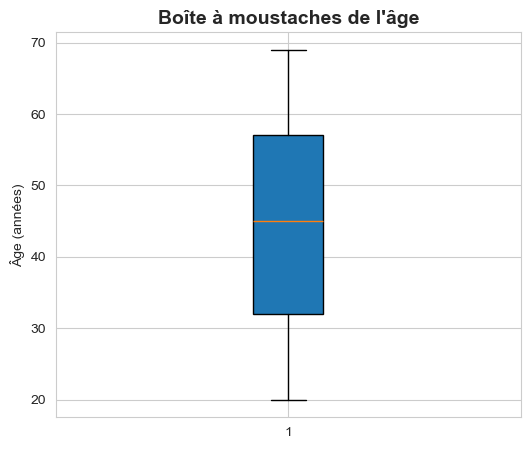

In [9]:
# Boxplot de l'âge
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    df['age'].dropna(),
    orientation='vertical',
    patch_artist=True
)

ax.set_title("Boîte à moustaches de l'âge", fontsize=14, fontweight='bold')
ax.set_ylabel("Âge (années)")

plt.show()

# 2.2 Distribution du Sexe (Genre)

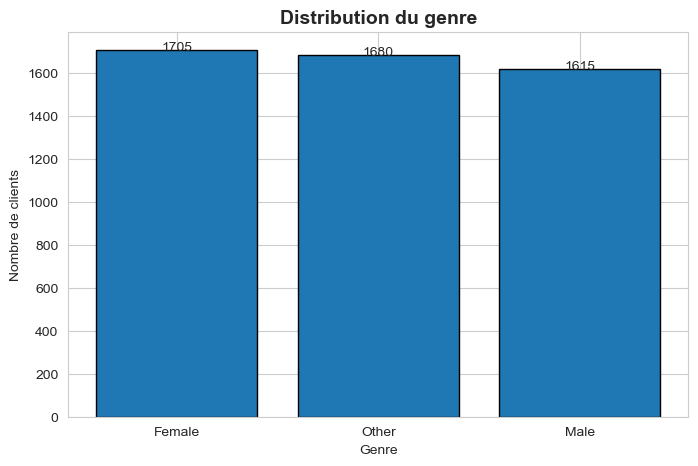

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

gender_counts = df['gender'].value_counts()

ax.bar(
    gender_counts.index,
    gender_counts.values,
    edgecolor='black'
)

ax.set_title("Distribution du genre", fontsize=14, fontweight='bold')
ax.set_xlabel("Genre")
ax.set_ylabel("Nombre de clients")

for i, v in enumerate(gender_counts.values):
    ax.text(i, v, str(v), ha='center')

plt.show()

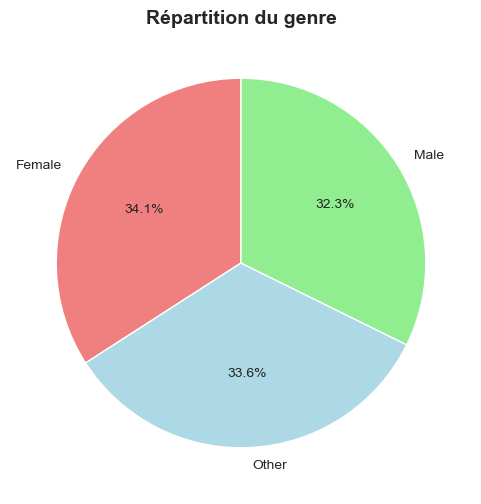

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'lightblue', 'lightgreen']
)

ax.set_title('Répartition du genre', fontsize=14, fontweight='bold')

plt.show()

# 2.3 Distribution du Statut Professionnel

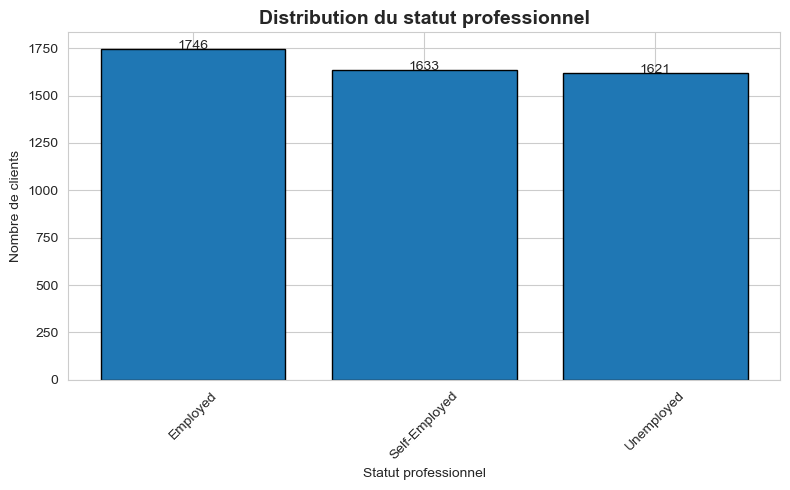

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

employment_counts = df['employment_status'].value_counts()

ax.bar(
    employment_counts.index,
    employment_counts.values,
    edgecolor='black'
)

ax.set_title('Distribution du statut professionnel', fontsize=14, fontweight='bold')
ax.set_xlabel('Statut professionnel')
ax.set_ylabel('Nombre de clients')

ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(employment_counts.values):
    ax.text(i, v, str(v), ha='center')

plt.tight_layout()
plt.show()

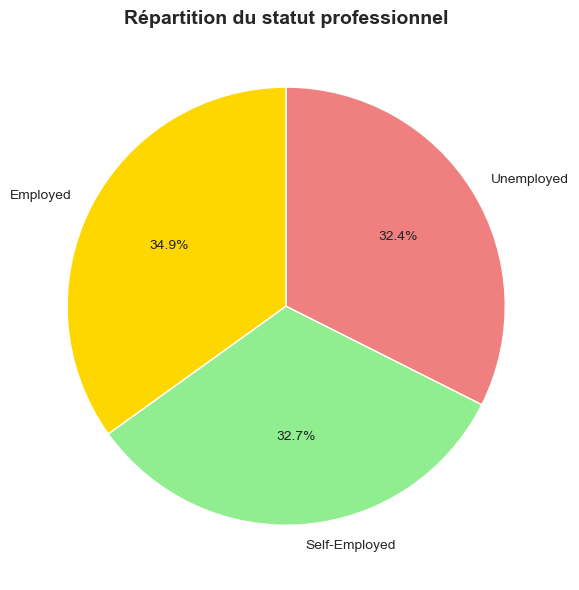

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.pie(
    employment_counts.values,
    labels=employment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightgreen', 'lightcoral', 'lightblue']
)

ax.set_title(
    'Répartition du statut professionnel',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 3. ANALYSE DES VARIABLES QUANTITATIVES
# ============================================================================


In [14]:
# Variables numériques
quantitative_vars = df.select_dtypes(include=[np.number]).columns.tolist()

# Détection des variables binaires
binary_vars = []

for col in quantitative_vars:
    unique_values = set(df[col].dropna().unique())

    if unique_values.issubset({0, 1}) and len(unique_values) <= 2:
        binary_vars.append(col)

# Variables quantitatives à analyser
exclude_cols = ['customer_id', 'user_id', 'id', 'person_id']

vars_to_analyze = [
    col for col in quantitative_vars
    if col not in binary_vars
    and col.lower() not in exclude_cols
]

print("Variables binaires :", binary_vars)
print("\nVariables quantitatives :", vars_to_analyze)

Variables binaires : ['loan_default_history', 'fraud_flag', 'credit_risk']

Variables quantitatives : ['age', 'annual_income', 'account_age_months', 'avg_monthly_balance', 'num_deposits_per_month', 'avg_deposit_amount', 'debit_card_usage_frequency', 'debit_card_spending', 'mobile_banking_logins', 'online_transfer_frequency', 'atm_withdrawal_frequency', 'credit_score', 'num_open_loans', 'total_outstanding_debt', 'late_payment_count', 'loan_application_amount']


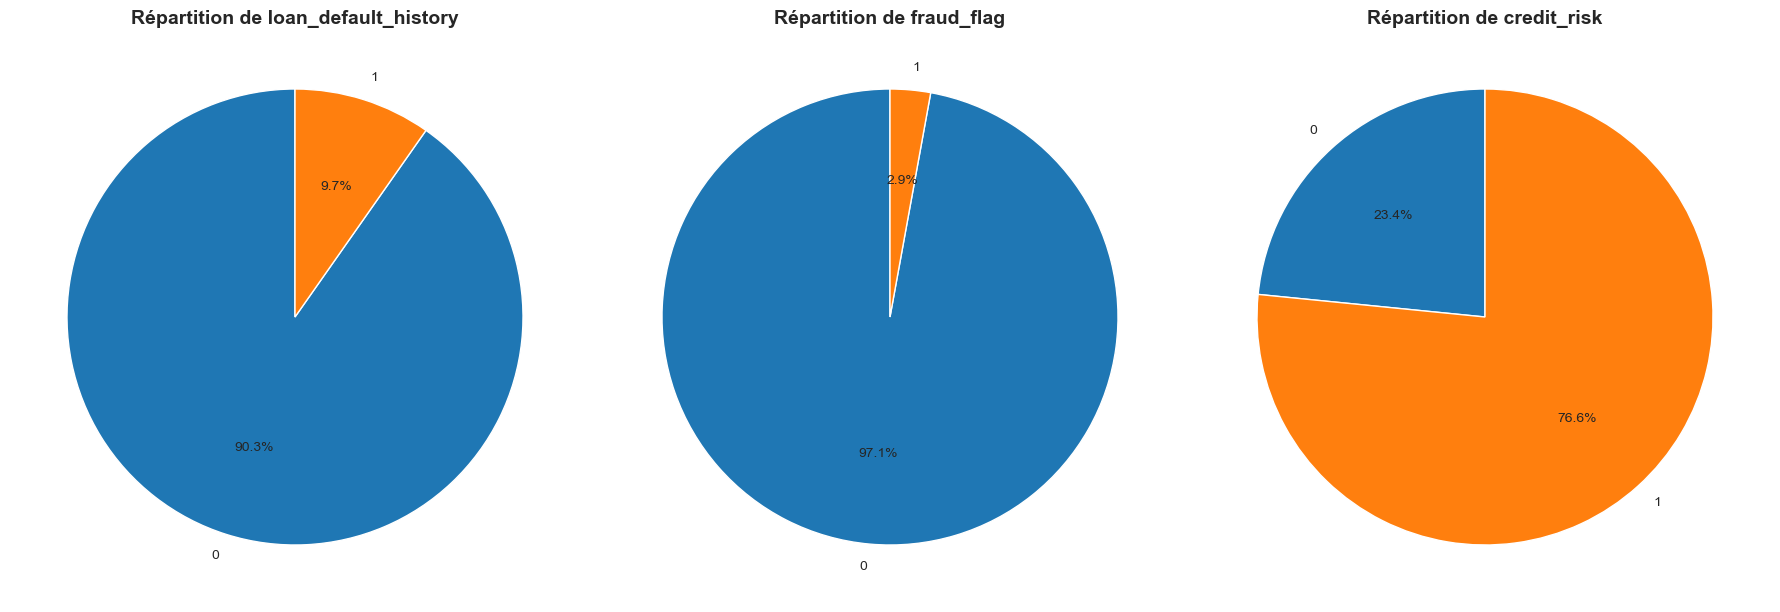

In [15]:
# Répartition des variables binaires

fig, axes = plt.subplots(1, len(binary_vars), figsize=(18, 6))

for ax, var in zip(axes, binary_vars):

    counts = df[var].value_counts().sort_index()

    ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(
        f"Répartition de {var}",
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

3.2 Histogrammes des variables quantitatives

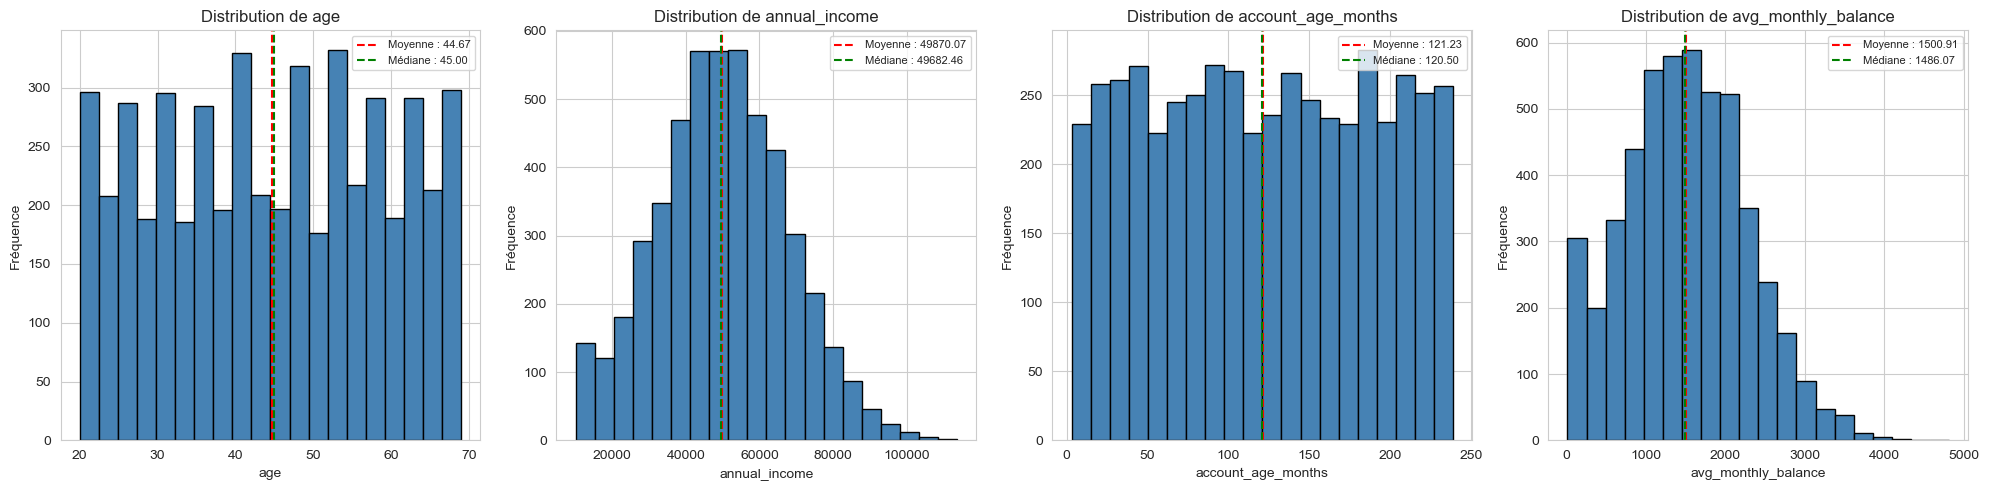

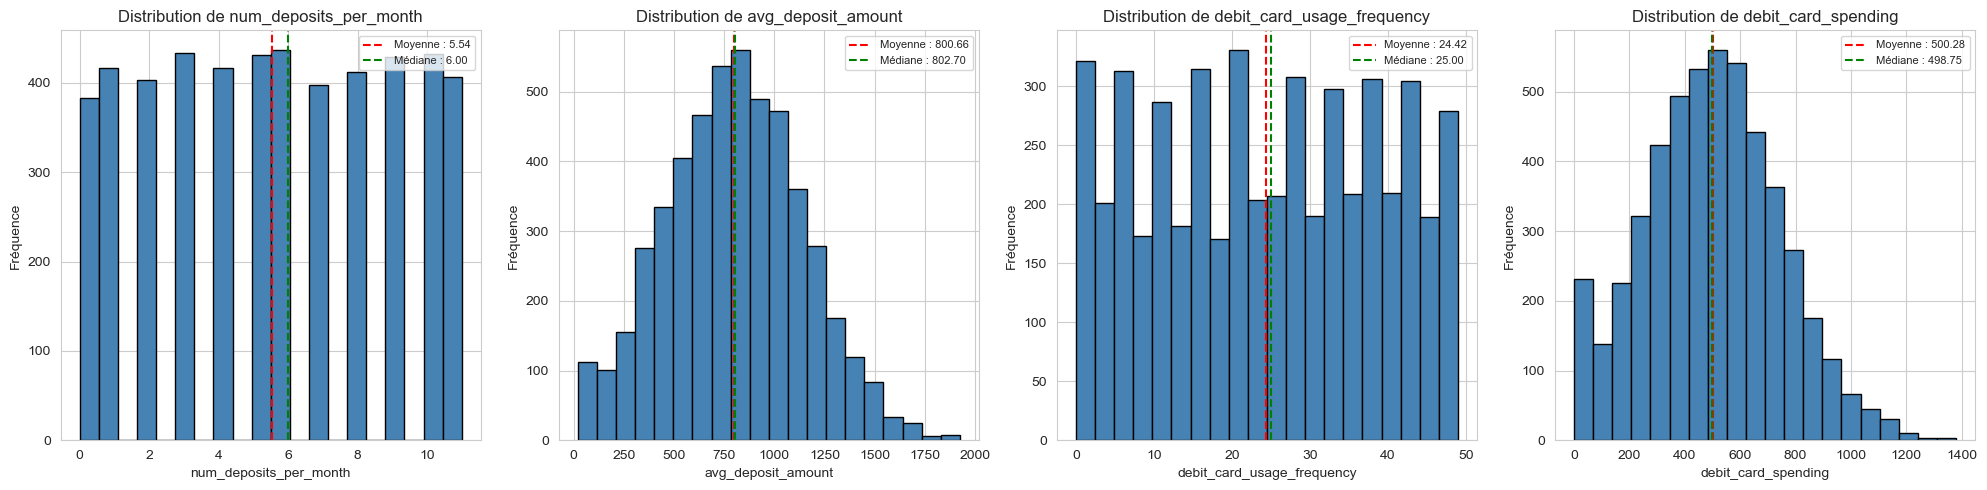

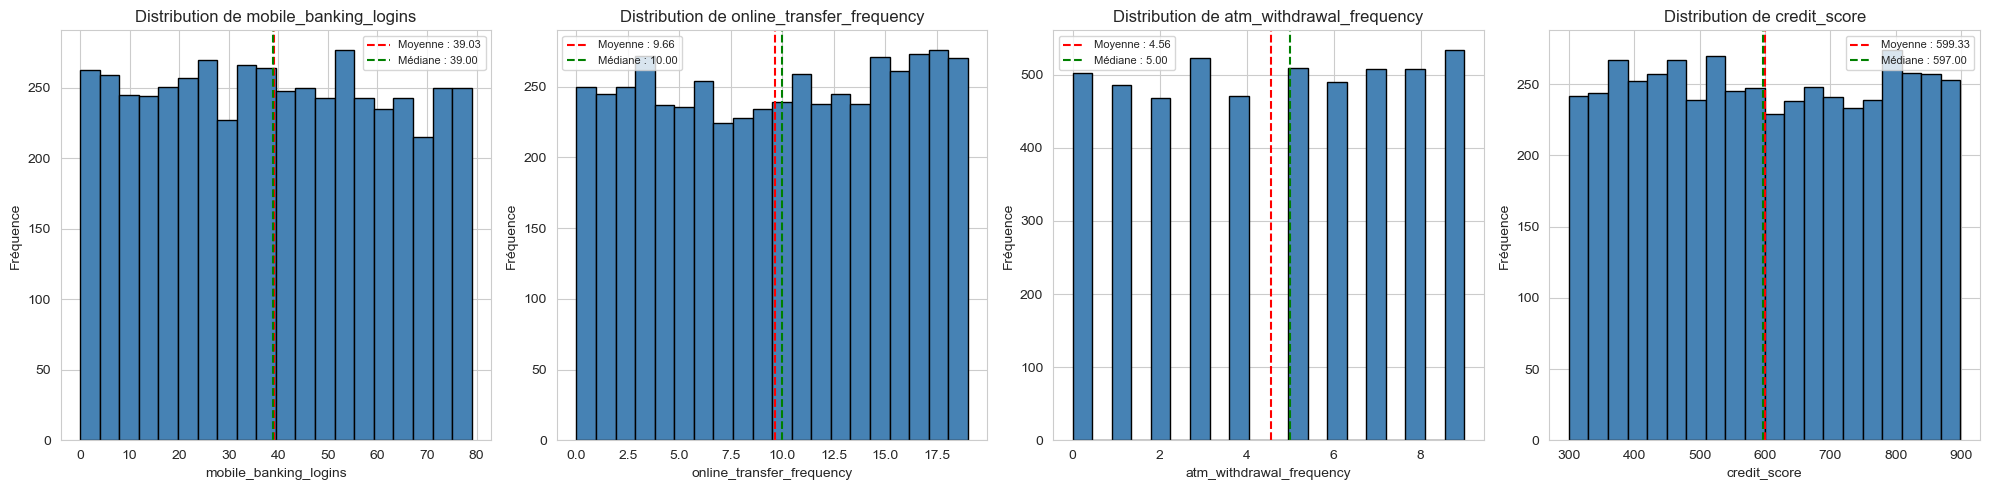

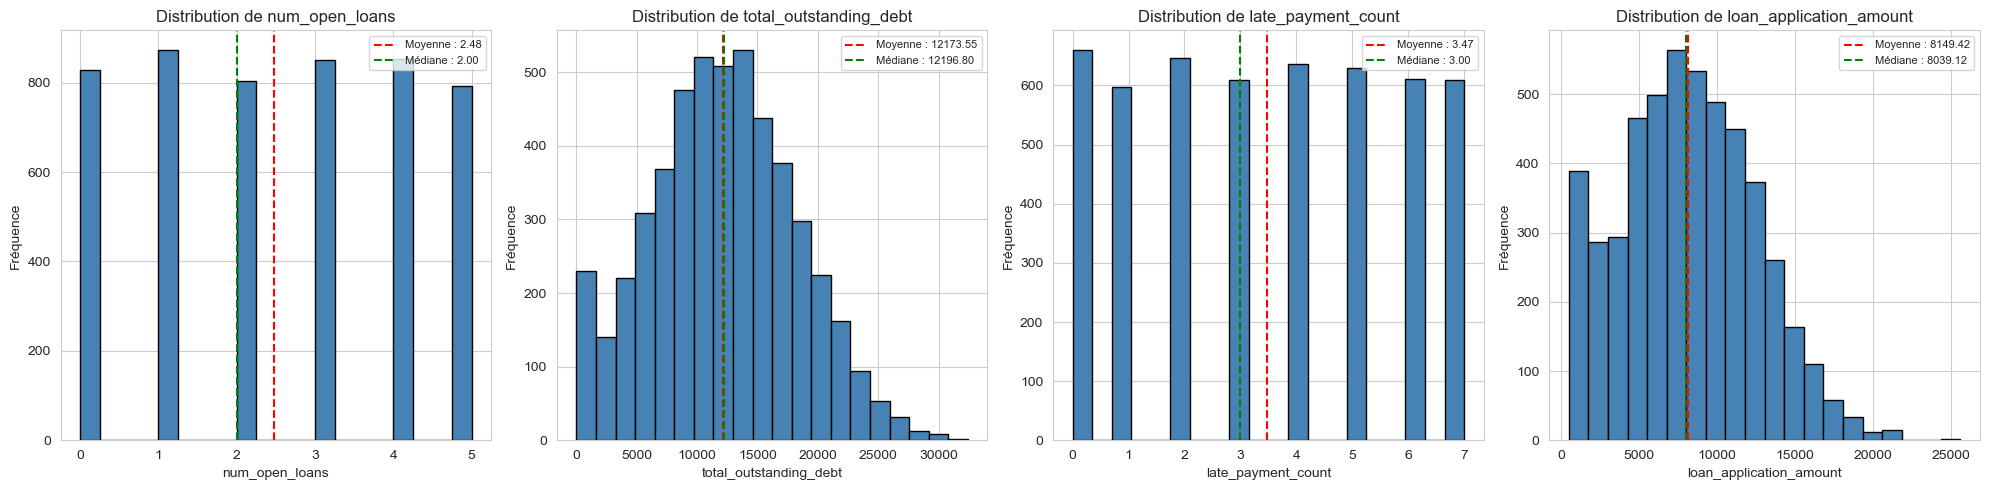

In [22]:


for i in range(0, len(vars_to_analyze), 4):

    vars_group = vars_to_analyze[i:i+4]

    fig, axes = plt.subplots(1, len(vars_group), figsize=(20, 5))

    # Cas où il ne reste qu'une seule variable
    if len(vars_group) == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_group):

        data = df[var].dropna()

        ax.hist(
            data,
            bins=20,
            color='steelblue',
            edgecolor='black'
        )

        ax.axvline(
            data.mean(),
            color='red',
            linestyle='--',
            label=f'Moyenne : {data.mean():.2f}'
        )

        ax.axvline(
            data.median(),
            color='green',
            linestyle='--',
            label=f'Médiane : {data.median():.2f}'
        )

        ax.set_title(f'Distribution de {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('Fréquence')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

Boxplots

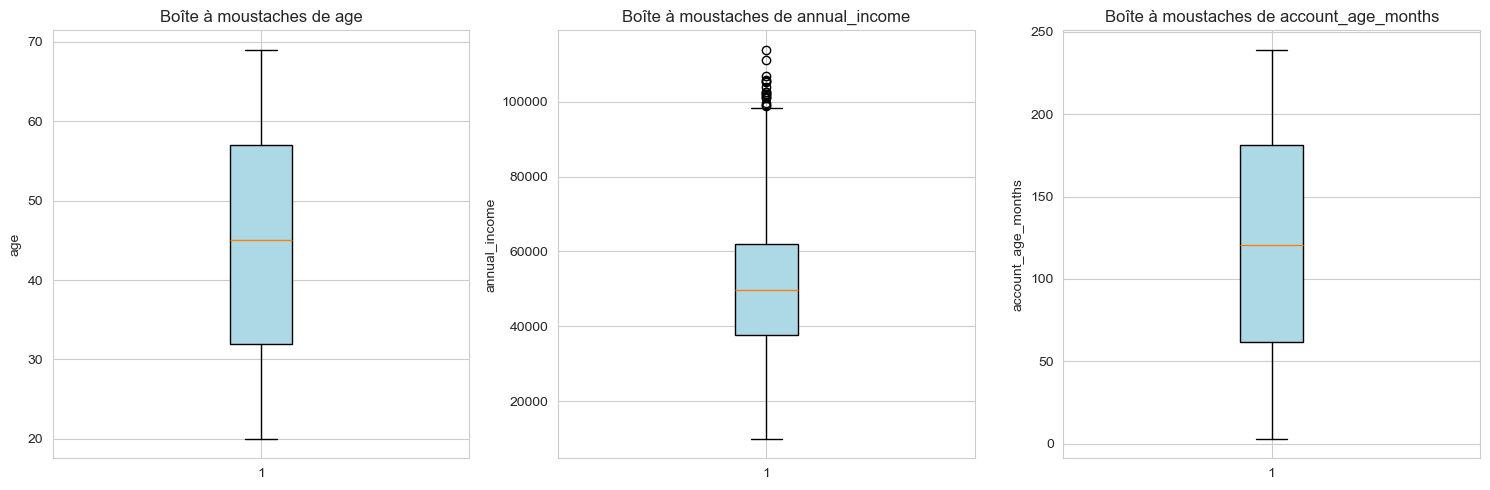

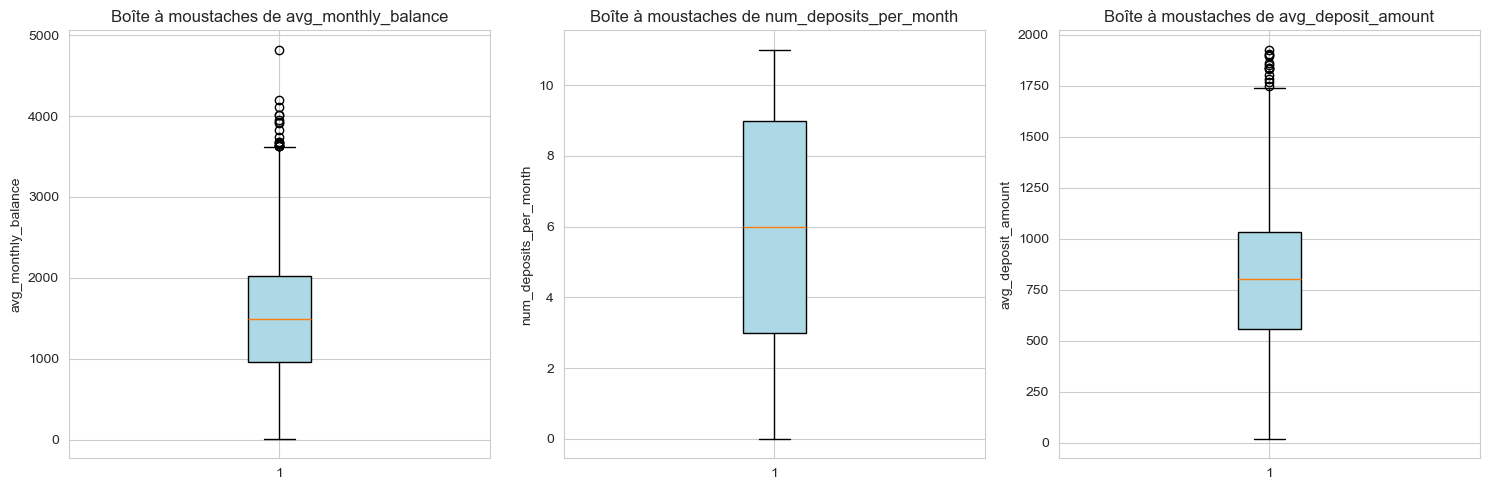

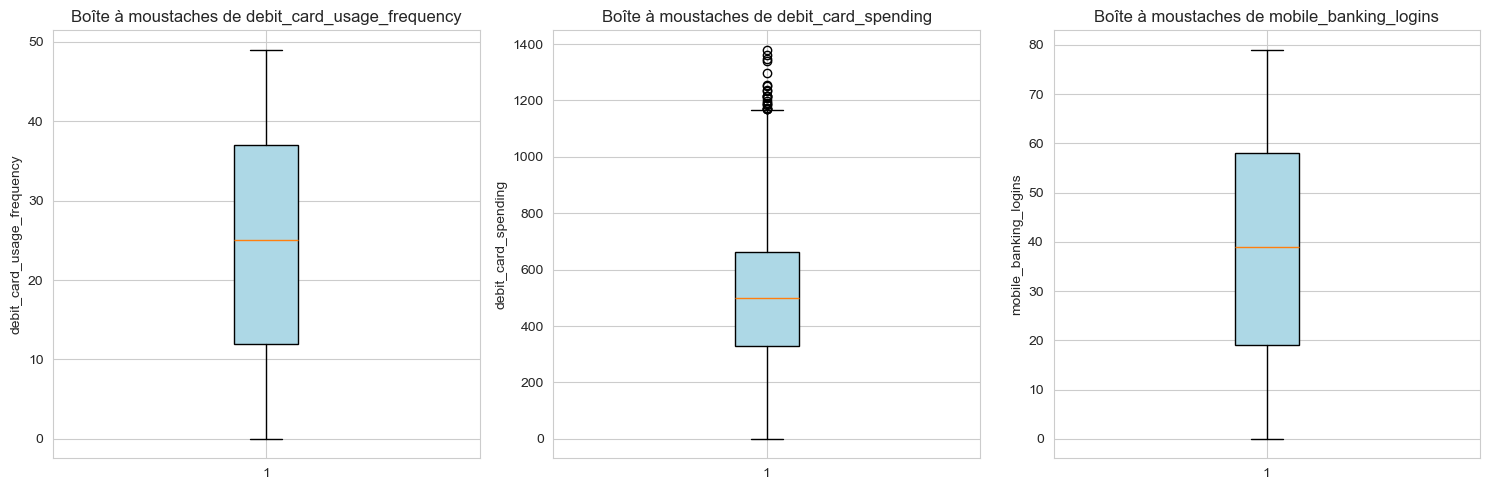

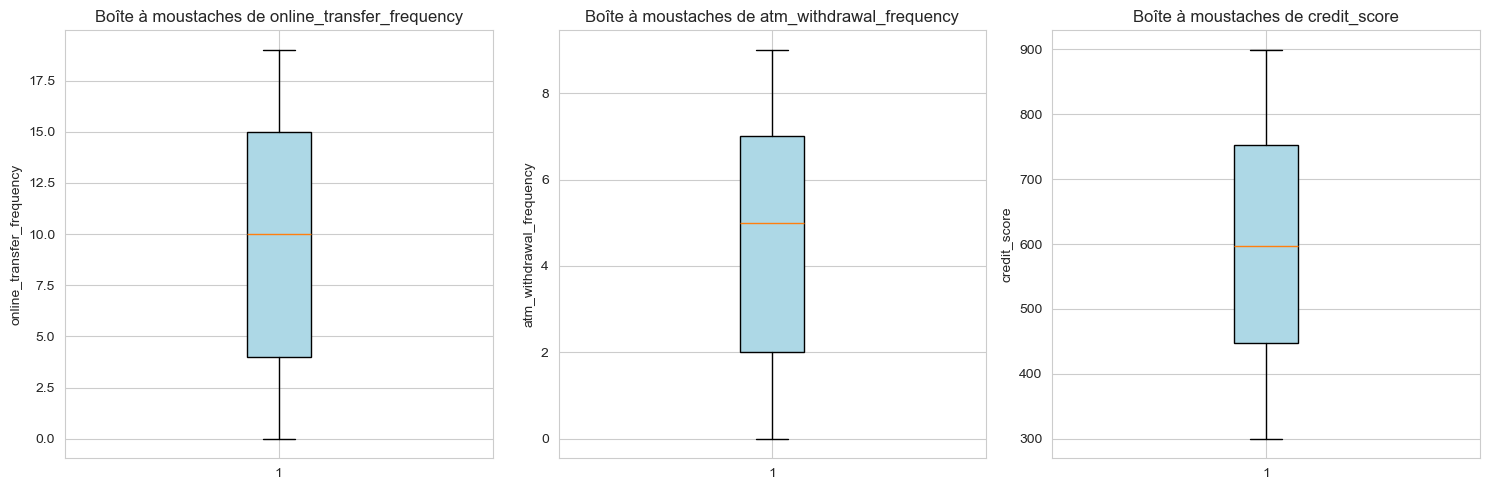

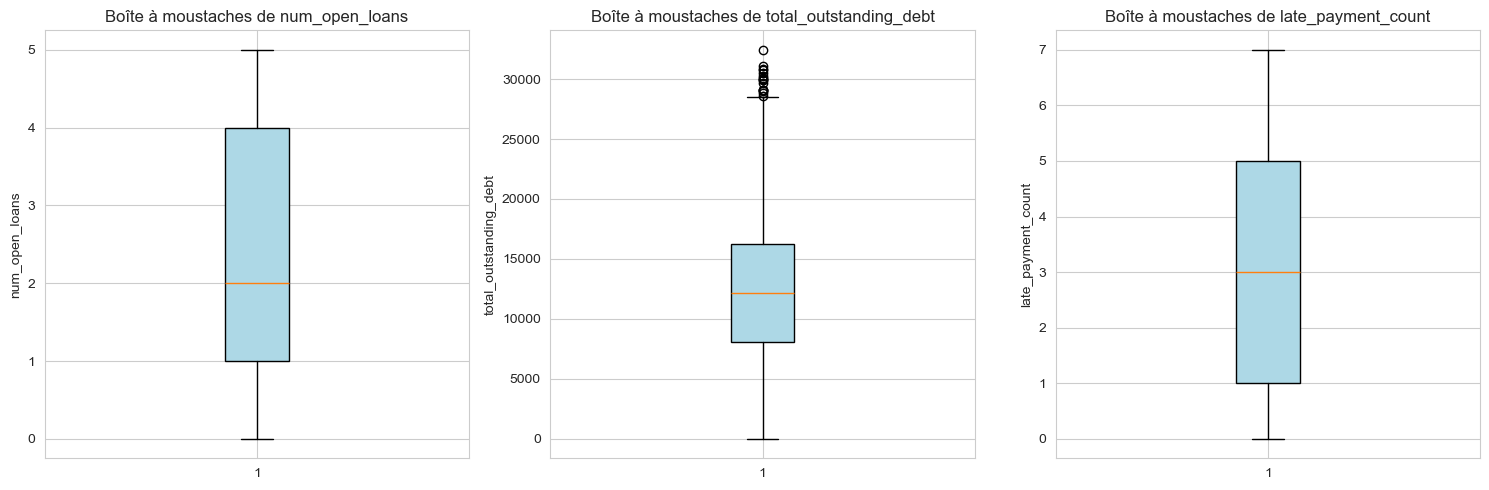

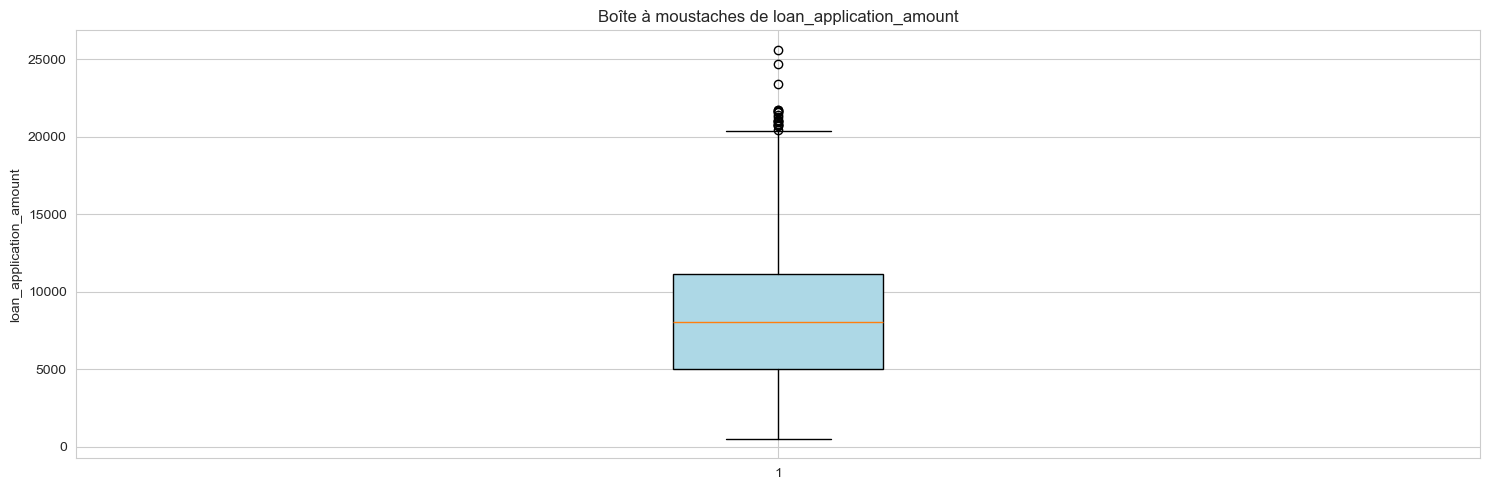

In [20]:

for i in range(0, len(vars_to_analyze), 3):

    vars_group = vars_to_analyze[i:i+3]

    fig, axes = plt.subplots(1, len(vars_group), figsize=(15, 5))

    # Cas où il ne reste qu'une seule variable
    if len(vars_group) == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_group):

        data = df[var].dropna()

        bp = ax.boxplot(
            data,
            patch_artist=True
        )

        bp['boxes'][0].set_facecolor('lightblue')

        ax.set_title(f"Boîte à moustaches de {var}")
        ax.set_ylabel(var)

    plt.tight_layout()
    plt.show()

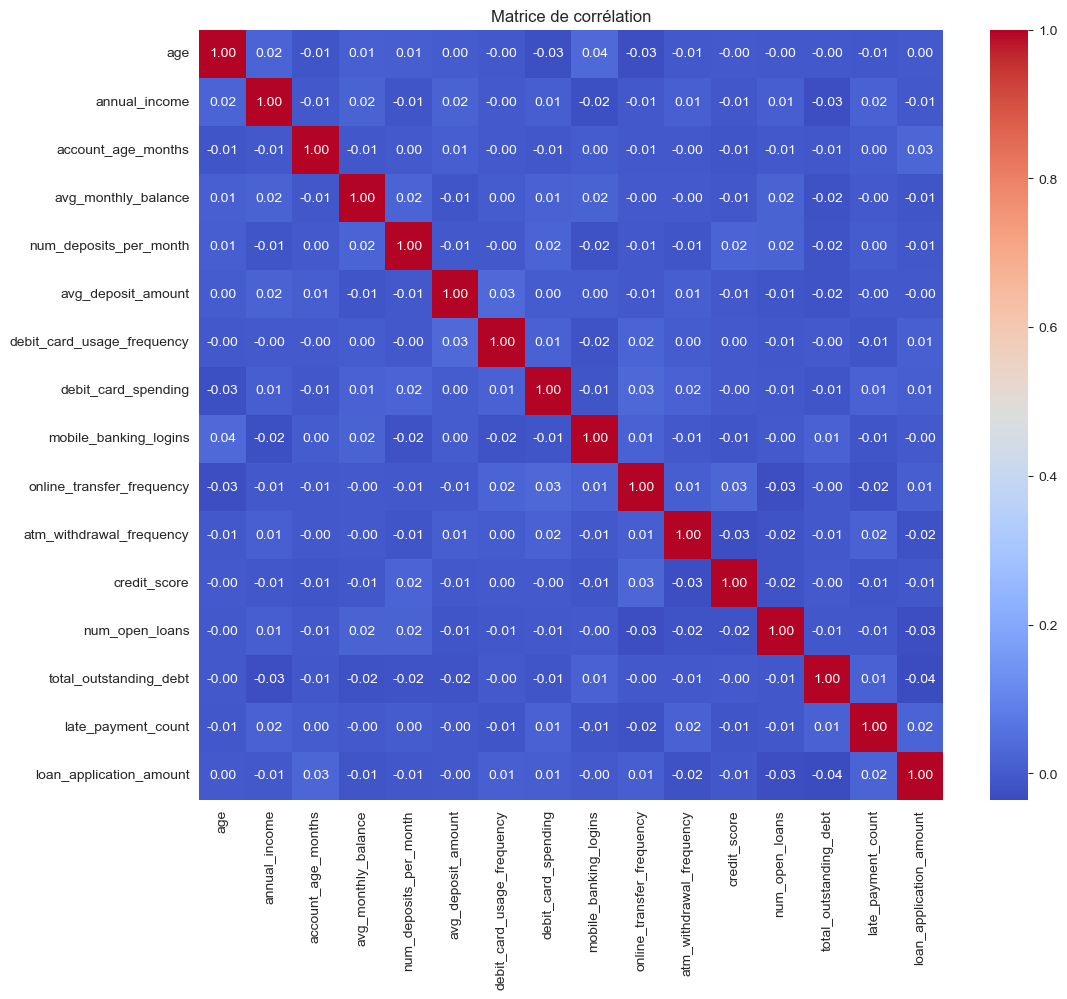

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))

corr = df[vars_to_analyze].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax
)

ax.set_title("Matrice de corrélation")

plt.show()

In [19]:
df[vars_to_analyze].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,44.666600,14.384312,20.0,32.000000,45.000000,57.000000,69.000000
annual_income,5000.0,49870.073961,17831.984829,10000.0,37633.483896,49682.456590,61964.226233,113793.170197
account_age_months,5000.0,121.226800,68.325584,3.0,62.000000,120.500000,181.000000,239.000000
avg_monthly_balance,5000.0,1500.912691,772.243462,10.0,958.522753,1486.067085,2024.758900,4818.316040
num_deposits_per_month,5000.0,5.542000,3.424118,0.0,3.000000,6.000000,9.000000,11.000000
avg_deposit_amount,5000.0,800.663464,341.229714,20.0,559.312932,802.695763,1033.796072,1925.380969
debit_card_usage_frequency,5000.0,24.424800,14.395172,0.0,12.000000,25.000000,37.000000,49.000000
debit_card_spending,5000.0,500.284845,245.167842,0.0,328.342032,498.752458,664.056885,1379.491843
mobile_banking_logins,5000.0,39.028000,23.039457,0.0,19.000000,39.000000,58.000000,79.000000
online_transfer_frequency,5000.0,9.660600,5.858248,0.0,4.000000,10.000000,15.000000,19.000000
